In [1]:
import pandas as pd

df = pd.read_excel("datos_for_eda.xlsx", engine="openpyxl")
diccionario = pd.read_excel("diccionario_datos_for_eda.xlsx", engine="openpyxl")

df.head()

,horas_sueno,vida_social,frecuencia_ejercicio,redes_sociales,nivel_estres,calidad_sueno,soledad_percibida,apoyo_familiar,autoestima,genero,estado_civil,target_depresion
0,7.9,4,0,2.5,2,3,1,3,4,1,2,0
1,7.4,3,2,1.2,2,3,1,4,4,1,0,0
2,8.0,3,2,0.6,1,4,2,3,4,2,2,0
3,8.7,4,2,2.6,2,4,1,3,4,2,1,0
4,7.3,3,0,2.6,2,4,2,4,3,2,5,0


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24209 entries, 0 to 24208
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   horas_sueno           24209 non-null  float64
 1   vida_social           24209 non-null  int64  
 2   frecuencia_ejercicio  24209 non-null  int64  
 3   redes_sociales        24209 non-null  float64
 4   nivel_estres          24209 non-null  int64  
 5   calidad_sueno         24209 non-null  int64  
 6   soledad_percibida     24209 non-null  int64  
 7   apoyo_familiar        24209 non-null  int64  
 8   autoestima            24209 non-null  int64  
 9   genero                24209 non-null  int64  
 10  estado_civil          24209 non-null  int64  
 11  target_depresion      24209 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 2.2 MB


MODELO 1 BINARIO ( TIENEO O NO TIENE DEPRESION)

In [4]:
# ==============================
# MODELO 1: DETECCIÓN BINARIA DE RIESGO DEPRESIVO
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier

In [5]:
# Crear target binario
# 0 = Sin depresión
# 1 = Con depresión

df["target_binario"] = df["target_depresion"].apply(
    lambda x: 0 if x == 0 else 1
)

In [6]:
# Revisar distribución

print(df["target_binario"].value_counts())
print(df["target_binario"].value_counts(normalize=True))

target_binario
0    19073
1     5136
Name: count, dtype: int64
target_binario
0    0.787847
1    0.212153
Name: proportion, dtype: float64


In [7]:
# Separar variables predictoras y target
# IMPORTANTE:
# Se excluye target_depresion, target_binario y target_riesgo para evitar data leakage

columnas_a_eliminar = [
    "target_depresion",
    "target_binario"
]

if "target_riesgo" in df.columns:
    columnas_a_eliminar.append("target_riesgo")

X_binario = df.drop(columns=columnas_a_eliminar)

y_binario = df["target_binario"]

In [8]:
# Train/Test Split

X_train_binario, X_test_binario, y_train_binario, y_test_binario = train_test_split(
    X_binario,
    y_binario,
    test_size=0.2,
    random_state=42,
    stratify=y_binario
)

In [9]:
# Encoding de variables categóricas

X_train_binario = pd.get_dummies(
    X_train_binario,
    columns=["genero", "estado_civil"],
    drop_first=True
)

X_test_binario = pd.get_dummies(
    X_test_binario,
    columns=["genero", "estado_civil"],
    drop_first=True
)

# Alinear columnas entre train y test
X_train_binario, X_test_binario = X_train_binario.align(
    X_test_binario,
    join="left",
    axis=1,
    fill_value=0
)

# Guardar columnas del modelo para recomendaciones/predicciones futuras
columnas_modelo_binario = X_train_binario.columns.tolist()

In [10]:
# Calcular balance de clases

negativos_binario = y_train_binario.value_counts()[0]
positivos_binario = y_train_binario.value_counts()[1]

scale_pos_binario = negativos_binario / positivos_binario

print("Scale Pos Weight:", scale_pos_binario)

Scale Pos Weight: 3.7133122414212703


In [11]:
# Entrenar modelo XGBoost binario

modelo_binario = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_binario,
    random_state=42,
    eval_metric="logloss"
)

modelo_binario.fit(X_train_binario, y_train_binario)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [12]:
# Predicciones

y_pred_binario = modelo_binario.predict(X_test_binario)
y_prob_binario = modelo_binario.predict_proba(X_test_binario)[:, 1]

In [13]:
# Evaluación

print("Accuracy:", accuracy_score(y_test_binario, y_pred_binario))
print("AUC ROC:", roc_auc_score(y_test_binario, y_prob_binario))

print("\nReporte de clasificación:")
print(classification_report(y_test_binario, y_pred_binario))

Accuracy: 0.869268897149938
AUC ROC: 0.9353249932044497

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      3815
           1       0.65      0.85      0.73      1027

    accuracy                           0.87      4842
   macro avg       0.80      0.86      0.82      4842
weighted avg       0.89      0.87      0.88      4842



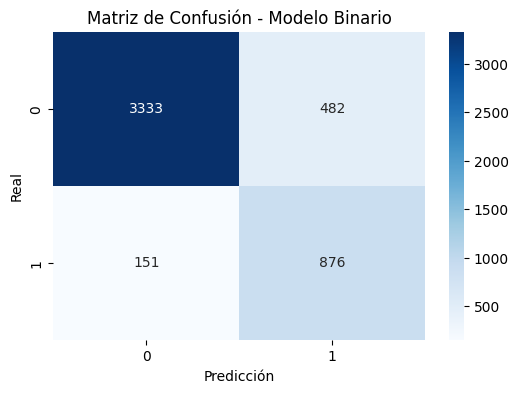

In [14]:
# Matriz de confusión

cm_binario = confusion_matrix(y_test_binario, y_pred_binario)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_binario, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Modelo Binario")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [15]:
# Importancia de variables

importancias_binario = pd.Series(
    modelo_binario.feature_importances_,
    index=columnas_modelo_binario
).sort_values(ascending=False)

importancias_binario

apoyo_familiar          0.408733
calidad_sueno           0.228456
vida_social             0.105705
nivel_estres            0.060343
autoestima              0.046684
horas_sueno             0.025771
soledad_percibida       0.020625
genero_2                0.019071
estado_civil_1          0.017377
estado_civil_5          0.014925
redes_sociales          0.014575
frecuencia_ejercicio    0.013830
estado_civil_2          0.012820
estado_civil_3          0.011084
estado_civil_4          0.000000
dtype: float32

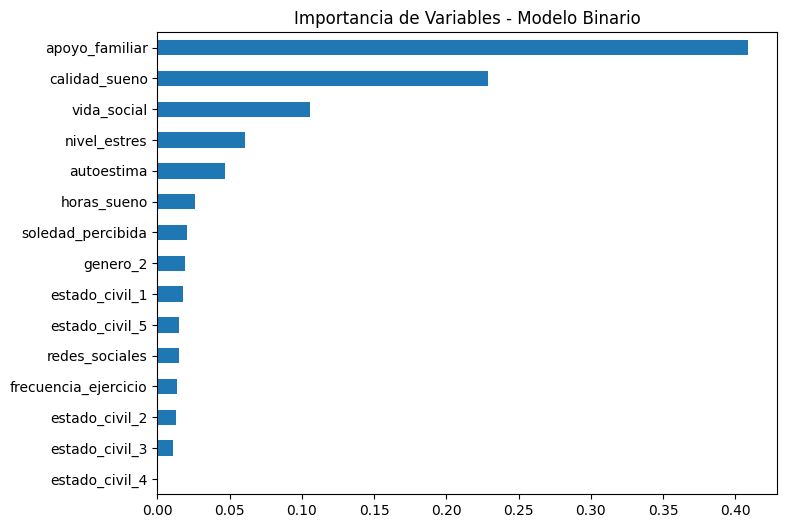

In [16]:
# Gráfico de importancia de variables

plt.figure(figsize=(8, 6))

importancias_binario.sort_values().plot(kind="barh")

plt.title("Importancia de Variables - Modelo Binario")
plt.show()

Objetivo del modelo

El primer modelo fue diseñado con el objetivo de identificar si un usuario presenta o no riesgo depresivo a partir de variables sociodemográficas, conductuales y psicosociales, sin utilizar directamente las preguntas del PHQ-9 como variables predictoras.

El target binario fue construido de la siguiente manera:

0 → Sin depresión
1 → Con depresión

La clasificación se basó en el resultado global obtenido mediante el PHQ-9, utilizándolo como referencia clínica de entrenamiento.

Variables utilizadas

El modelo utilizó variables externas relacionadas con hábitos, entorno social y estado emocional general:

horas_sueno
vida_social
frecuencia_ejercicio
redes_sociales
nivel_estres
calidad_sueno
soledad_percibida
apoyo_familiar
autoestima
genero
estado_civil

Estas variables fueron seleccionadas debido a su asociación con factores de riesgo y protección en salud mental.

Resultados obtenidos

El modelo obtuvo los siguientes resultados:

Accuracy: 86.9%
AUC ROC: 93.5%
Recall clase positiva: 85%
F1-score clase positiva: 73%

El valor AUC ROC de 0.935 indica una excelente capacidad del modelo para diferenciar usuarios con y sin riesgo depresivo.

Asimismo, el recall de 85% demuestra que el modelo logra detectar correctamente la mayoría de los casos positivos, reduciendo el riesgo de falsos negativos.

Variables más importantes

Las variables con mayor relevancia predictiva fueron:

apoyo_familiar
calidad_sueno
vida_social
nivel_estres
autoestima

Esto evidencia que los factores psicosociales y emocionales tienen una fuerte relación con el riesgo depresivo dentro del dataset analizado.

Justificación y factibilidad

Este modelo es factible porque permite realizar una detección preventiva de riesgo depresivo utilizando únicamente variables externas y de comportamiento, sin depender directamente de un cuestionario clínico completo.

Además, su estructura permite integrarse fácilmente en una aplicación web para:

monitoreo preventivo,
generación de recomendaciones,
identificación temprana de riesgo.

El modelo no busca reemplazar un diagnóstico profesional, sino funcionar como un sistema de apoyo preventivo basado en inteligencia artificial.

MODELO 2 : CLASIFICACION

In [17]:
def clasificar_riesgo(x):
    if x in [0, 1]:
        return 0   # Bajo
    elif x == 2:
        return 1   # Moderado
    else:
        return 2   # Alto


df["target_riesgo"] = df["target_depresion"].apply(clasificar_riesgo)

In [18]:
df["target_riesgo"].value_counts()

target_riesgo
0    22813
1      915
2      481
Name: count, dtype: int64

In [19]:
df["target_riesgo"].value_counts(normalize=True)

target_riesgo
0    0.942335
1    0.037796
2    0.019869
Name: proportion, dtype: float64

In [20]:
df_severidad = df[df["target_depresion"] != 0].copy()

In [21]:
def clasificar_severidad(x):
    if x == 1:
        return 0   # Leve
    else:
        return 1   # Moderado/Alto


df_severidad["target_severidad"] = df_severidad["target_depresion"].apply(clasificar_severidad)

In [22]:
df_severidad["target_severidad"].value_counts()

target_severidad
0    3740
1    1396
Name: count, dtype: int64

In [23]:
df_severidad["target_severidad"].value_counts(normalize=True)

target_severidad
0    0.728193
1    0.271807
Name: proportion, dtype: float64

In [24]:
X_severidad = df_severidad.drop(
    columns=[
        "target_depresion",
        "target_binario",
        "target_riesgo",
        "target_severidad"
    ]
)

y_severidad = df_severidad["target_severidad"]

In [25]:
from sklearn.model_selection import train_test_split

X_train_severidad, X_test_severidad, y_train_severidad, y_test_severidad = train_test_split(
    X_severidad,
    y_severidad,
    test_size=0.2,
    random_state=42,
    stratify=y_severidad
)

In [26]:
import pandas as pd

X_train_severidad = pd.get_dummies(
    X_train_severidad,
    columns=["genero", "estado_civil"],
    drop_first=True
)

X_test_severidad = pd.get_dummies(
    X_test_severidad,
    columns=["genero", "estado_civil"],
    drop_first=True
)

X_train_severidad, X_test_severidad = X_train_severidad.align(
    X_test_severidad,
    join="left",
    axis=1,
    fill_value=0
)

In [27]:
columnas_modelo_severidad = X_train_severidad.columns.tolist()

In [28]:
negativos_severidad = y_train_severidad.value_counts()[0]
positivos_severidad = y_train_severidad.value_counts()[1]

scale_pos_severidad = negativos_severidad / positivos_severidad

print(scale_pos_severidad)

2.6777081468218444


In [29]:
from xgboost import XGBClassifier

modelo_severidad = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_severidad,
    random_state=42,
    eval_metric="logloss"
)

modelo_severidad.fit(X_train_severidad, y_train_severidad)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [30]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred_severidad = modelo_severidad.predict(X_test_severidad)
y_prob_severidad = modelo_severidad.predict_proba(X_test_severidad)[:, 1]

print("Accuracy:", accuracy_score(y_test_severidad, y_pred_severidad))
print("AUC ROC:", roc_auc_score(y_test_severidad, y_prob_severidad))
print(classification_report(y_test_severidad, y_pred_severidad))

Accuracy: 0.9319066147859922
AUC ROC: 0.9726708490651813
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       749
           1       0.85      0.90      0.88       279

    accuracy                           0.93      1028
   macro avg       0.91      0.92      0.92      1028
weighted avg       0.93      0.93      0.93      1028



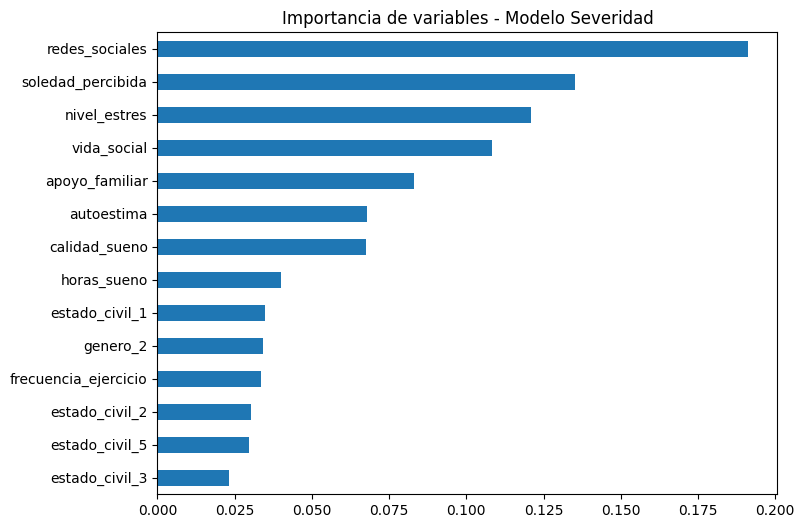

In [31]:
import matplotlib.pyplot as plt

importancias_severidad = pd.Series(
    modelo_severidad.feature_importances_,
    index=X_train_severidad.columns
).sort_values()

plt.figure(figsize=(8, 6))
importancias_severidad.plot(kind="barh")
plt.title("Importancia de variables - Modelo Severidad")
plt.show()

Clasificación de Severidad Depresiva
Objetivo del modelo

El Modelo 2 fue diseñado para clasificar el nivel de severidad depresiva únicamente en usuarios previamente identificados con riesgo depresivo por el Modelo 1.

Para ello, se excluyeron los casos sin depresión y se construyó un nuevo target binario:

0 → Depresión leve
1 → Depresión moderada/alta

La agrupación se realizó debido al fuerte desbalance presente en las categorías severas del dataset original.

Interpretación de resultados

El modelo alcanzó un AUC ROC de 0.972, evidenciando una capacidad extremadamente alta para diferenciar casos leves de casos moderados o altos.

Asimismo, el recall de 90% demuestra que el sistema logra identificar correctamente la mayoría de los casos clínicamente más preocupantes.

Esto resulta relevante porque permite priorizar usuarios que podrían requerir un seguimiento más cercano o una recomendación de apoyo profesional.

Inicialmente se intentó implementar un modelo multiclase utilizando todas las categorías originales del PHQ-9; sin embargo, se identificó un fuerte desbalance en las clases severas, lo cual afectaba negativamente la estabilidad y capacidad predictiva del modelo.

Por ello, se optó por una arquitectura escalonada:

Un primer modelo encargado de detectar riesgo depresivo.
Un segundo modelo especializado únicamente en clasificar severidad entre usuarios positivos.

Esta estrategia permitió:

reducir el impacto del desbalance,
mejorar la capacidad predictiva,
aumentar la interpretabilidad clínica,
y construir modelos más especializados.

HALLAZGOS GENREALES DEL PROYECTO Y MODELOS :

. Factibilidad del enfoque predictivo

Los resultados obtenidos demuestran que es factible identificar patrones asociados al riesgo depresivo utilizando variables externas relacionadas con hábitos, entorno social y estado emocional general, sin depender directamente de las preguntas clínicas del PHQ-9 como variables predictoras


2. Relevancia de factores psicosociales

Las variables con mayor importancia predictiva estuvieron principalmente relacionadas con:

apoyo familiar,
calidad del sueño,
vida social,
autoestima,
nivel de estrés.

Esto evidencia que los factores emocionales y sociales poseen una fuerte relación con el riesgo depresivo dentro de la población analizada.


3. Limitaciones del enfoque multiclase tradicional

Se observó que utilizar directamente todas las categorías originales del PHQ-9 generaba problemas importantes de desbalance de clases, especialmente en los niveles severos.

Por ello, una arquitectura escalonada basada en múltiples modelos resultó más estable y efectiva.

4. Ventajas del enfoque escalonado

La implementación de dos modelos especializados permitió:

mejorar el desempeño predictivo,
reducir problemas de desbalance,
aumentar la interpretabilidad,
y generar recomendaciones diferenciadas según el nivel de riesgo.


5. Potencial de aplicación práctica
El sistema desarrollado posee potencial para implementarse como una herramienta digital de apoyo preventivo en salud mental, permitiendo:


detección temprana,


monitoreo periódico,


clasificación de severidad,


y generación de recomendaciones personalizadas.


No obstante, el sistema no busca reemplazar un diagnóstico profesional, sino funcionar como una herramienta complementaria de apoyo y prevención.

SISTEMA DE RECOMENDACIONES

In [32]:
# ==============================
# SISTEMA DE RECOMENDACIONES
# ==============================

import pandas as pd

In [33]:
# Asegurar columnas exactas usadas por cada modelo

columnas_modelo_binario = X_train_binario.columns.tolist()
columnas_modelo_severidad = X_train_severidad.columns.tolist()

In [34]:
# Importancias del modelo binario para priorizar recomendaciones

importancias_binario = pd.Series(
    modelo_binario.feature_importances_,
    index=columnas_modelo_binario
).sort_values(ascending=False)

importancias_binario

apoyo_familiar          0.408733
calidad_sueno           0.228456
vida_social             0.105705
nivel_estres            0.060343
autoestima              0.046684
horas_sueno             0.025771
soledad_percibida       0.020625
genero_2                0.019071
estado_civil_1          0.017377
estado_civil_5          0.014925
redes_sociales          0.014575
frecuencia_ejercicio    0.013830
estado_civil_2          0.012820
estado_civil_3          0.011084
estado_civil_4          0.000000
dtype: float32

In [35]:
def preparar_usuario(usuario, columnas_modelo):
    usuario_df = pd.DataFrame([usuario])

    usuario_df = pd.get_dummies(
        usuario_df,
        columns=["genero", "estado_civil"],
        drop_first=True
    )

    usuario_df = usuario_df.reindex(
        columns=columnas_modelo,
        fill_value=0
    )

    return usuario_df

In [36]:
def interpretar_riesgo(valor):
    return "Con riesgo depresivo" if valor == 1 else "Sin riesgo depresivo"


def interpretar_severidad(valor):
    if valor is None:
        return "No aplica"
    return "Moderado/Alto" if valor == 1 else "Leve"

In [37]:
def generar_recomendaciones(usuario, riesgo_binario, severidad, importancias_modelo):
    recomendaciones = []

    reglas = {
        "apoyo_familiar": {
            "condicion": usuario["apoyo_familiar"] <= 2,
            "mensaje": "Fortalecer la red de apoyo familiar y fomentar espacios de comunicación con personas de confianza.",
            "gravedad": 4 - usuario["apoyo_familiar"]
        },
        "calidad_sueno": {
            "condicion": usuario["calidad_sueno"] <= 2,
            "mensaje": "Mejorar la higiene del sueño: mantener horarios regulares, reducir pantallas antes de dormir y evitar cafeína durante la noche.",
            "gravedad": 4 - usuario["calidad_sueno"]
        },
        "vida_social": {
            "condicion": usuario["vida_social"] <= 2,
            "mensaje": "Incrementar gradualmente las actividades sociales y el contacto con amigos, familiares o grupos de apoyo.",
            "gravedad": 4 - usuario["vida_social"]
        },
        "nivel_estres": {
            "condicion": usuario["nivel_estres"] >= 3,
            "mensaje": "Aplicar técnicas de manejo del estrés, como respiración profunda, pausas activas y organización de actividades.",
            "gravedad": usuario["nivel_estres"]
        },
        "autoestima": {
            "condicion": usuario["autoestima"] <= 2,
            "mensaje": "Realizar actividades de refuerzo personal, reconocimiento de logros y seguimiento emocional.",
            "gravedad": 4 - usuario["autoestima"]
        },
        "horas_sueno": {
            "condicion": usuario["horas_sueno"] < 6,
            "mensaje": "Incrementar progresivamente las horas de descanso hasta alcanzar un rango saludable de sueño.",
            "gravedad": 6 - usuario["horas_sueno"]
        },
        "soledad_percibida": {
            "condicion": usuario["soledad_percibida"] >= 3,
            "mensaje": "Reducir la sensación de aislamiento mediante actividades sociales graduales y fortalecimiento de vínculos cercanos.",
            "gravedad": usuario["soledad_percibida"]
        },
        "redes_sociales": {
            "condicion": usuario["redes_sociales"] >= 7,
            "mensaje": "Reducir progresivamente el tiempo de uso de redes sociales y reemplazarlo por actividades recreativas offline.",
            "gravedad": usuario["redes_sociales"] - 6
        },
        "frecuencia_ejercicio": {
            "condicion": usuario["frecuencia_ejercicio"] == 0,
            "mensaje": "Iniciar actividad física ligera 2 a 3 veces por semana, como caminatas o ejercicios suaves.",
            "gravedad": 2
        }
    }

    for variable, regla in reglas.items():
        if regla["condicion"]:
            importancia = importancias_modelo.get(variable, 0.01)
            score = importancia * regla["gravedad"]

            recomendaciones.append({
                "variable_origen": variable,
                "importancia_modelo": round(importancia, 4),
                "score_prioridad": round(score, 4),
                "recomendacion": regla["mensaje"]
            })

    recomendaciones = sorted(
        recomendaciones,
        key=lambda x: x["score_prioridad"],
        reverse=True
    )

    if riesgo_binario == 0:
        recomendaciones.insert(0, {
            "variable_origen": "riesgo_general",
            "importancia_modelo": 0,
            "score_prioridad": 0,
            "recomendacion": "El usuario no presenta riesgo depresivo según el modelo. Se recomienda mantener hábitos saludables y realizar monitoreo preventivo periódico."
        })

    elif severidad == 1:
        recomendaciones.insert(0, {
            "variable_origen": "severidad",
            "importancia_modelo": 1,
            "score_prioridad": 999,
            "recomendacion": "El usuario presenta riesgo moderado/alto. Se recomienda seguimiento prioritario y considerar orientación profesional."
        })

    else:
        recomendaciones.insert(0, {
            "variable_origen": "severidad",
            "importancia_modelo": 1,
            "score_prioridad": 500,
            "recomendacion": "El usuario presenta riesgo leve. Se recomienda monitoreo preventivo y mejora gradual de hábitos."
        })

    return pd.DataFrame(recomendaciones)

In [38]:
def generar_recomendaciones_interaccion(usuario, importancias_modelo):
    recomendaciones = []

    reglas_interaccion = [
        {
            "variables": ["apoyo_familiar", "autoestima"],
            "condicion": usuario["apoyo_familiar"] <= 2 and usuario["autoestima"] <= 2,
            "mensaje": "Se observa bajo apoyo familiar junto con baja autoestima. Se recomienda fortalecer redes de apoyo cercanas y realizar actividades de refuerzo personal.",
            "gravedad": (4 - usuario["apoyo_familiar"]) + (4 - usuario["autoestima"])
        },
        {
            "variables": ["calidad_sueno", "nivel_estres"],
            "condicion": usuario["calidad_sueno"] <= 2 and usuario["nivel_estres"] >= 3,
            "mensaje": "Se observa mala calidad de sueño junto con alto nivel de estrés. Se recomienda trabajar una rutina de descanso y aplicar técnicas de regulación del estrés.",
            "gravedad": (4 - usuario["calidad_sueno"]) + usuario["nivel_estres"]
        },
        {
            "variables": ["vida_social", "soledad_percibida"],
            "condicion": usuario["vida_social"] <= 2 and usuario["soledad_percibida"] >= 3,
            "mensaje": "Se observa baja vida social junto con alta soledad percibida. Se recomienda incrementar gradualmente el contacto con personas de confianza o actividades sociales seguras.",
            "gravedad": (4 - usuario["vida_social"]) + usuario["soledad_percibida"]
        },
        {
            "variables": ["redes_sociales", "horas_sueno"],
            "condicion": usuario["redes_sociales"] >= 7 and usuario["horas_sueno"] < 6,
            "mensaje": "Se observa uso elevado de redes sociales junto con pocas horas de sueño. Se recomienda reducir pantallas antes de dormir y establecer horarios regulares de descanso.",
            "gravedad": (usuario["redes_sociales"] - 6) + (6 - usuario["horas_sueno"])
        },
        {
            "variables": ["frecuencia_ejercicio", "nivel_estres"],
            "condicion": usuario["frecuencia_ejercicio"] == 0 and usuario["nivel_estres"] >= 3,
            "mensaje": "Se observa inactividad física junto con alto estrés. Se recomienda iniciar actividad física ligera, como caminatas cortas, para apoyar la regulación emocional.",
            "gravedad": 2 + usuario["nivel_estres"]
        }
    ]

    for regla in reglas_interaccion:
        if regla["condicion"]:
            importancia_promedio = sum(
                importancias_modelo.get(var, 0.01)
                for var in regla["variables"]
            ) / len(regla["variables"])

            # Multiplicador para que las interacciones tengan más prioridad
            score = importancia_promedio * regla["gravedad"] * 2

            recomendaciones.append({
                "tipo": "Interacción entre variables",
                "variable_origen": " + ".join(regla["variables"]),
                "importancia_modelo": round(importancia_promedio, 4),
                "score_prioridad": round(score, 4),
                "recomendacion": regla["mensaje"]
            })

    return pd.DataFrame(recomendaciones)

In [128]:
usuario = {
    "horas_sueno": 6,
    "vida_social": 1,
    "frecuencia_ejercicio": 2,
    "redes_sociales": 4,
    "nivel_estres": 2,
    "calidad_sueno": 1,
    "soledad_percibida": 2,
    "apoyo_familiar": 2,
    "autoestima": 5,
    "genero": 1,
    "estado_civil": 0
}

In [129]:
# Preparar usuario para cada modelo con sus propias columnas

usuario_encoded_binario = preparar_usuario(
    usuario,
    columnas_modelo_binario
)

usuario_encoded_severidad = preparar_usuario(
    usuario,
    columnas_modelo_severidad
)

In [130]:
# MODELO 1: riesgo depresivo

prob_riesgo = modelo_binario.predict_proba(usuario_encoded_binario)[:, 1][0]

riesgo_binario = 1 if prob_riesgo >= 0.5 else 0

print("Probabilidad de riesgo:", round(prob_riesgo, 4))
print("Resultado:", interpretar_riesgo(riesgo_binario))

Probabilidad de riesgo: 0.9931
Resultado: Con riesgo depresivo


In [131]:
# MODELO 2: severidad
# Solo se ejecuta si el Modelo 1 detecta riesgo

if riesgo_binario == 1:
    prob_severidad = modelo_severidad.predict_proba(usuario_encoded_severidad)[:, 1][0]
    severidad = 1 if prob_severidad >= 0.5 else 0
else:
    prob_severidad = None
    severidad = None

print("Probabilidad severidad:", None if prob_severidad is None else round(prob_severidad, 4))
print("Severidad:", interpretar_severidad(severidad))

Probabilidad severidad: 0.3568
Severidad: Leve


In [132]:
recomendaciones_individuales = generar_recomendaciones(
    usuario=usuario,
    riesgo_binario=riesgo_binario,
    severidad=severidad,
    importancias_modelo=importancias_binario
)

recomendaciones_individuales["tipo"] = "Individual"

recomendaciones_interaccion = generar_recomendaciones_interaccion(
    usuario=usuario,
    importancias_modelo=importancias_binario
)

recomendaciones_finales = pd.concat(
    [
        recomendaciones_interaccion,
        recomendaciones_individuales
    ],
    ignore_index=True
).sort_values(
    by=["tipo", "score_prioridad"],
    ascending=[True, False]
)

recomendaciones_finales

,variable_origen,importancia_modelo,score_prioridad,recomendacion,tipo
0,severidad,1.0000,500.0000,El usuario presenta riesgo leve. Se recomienda...,Individual
1,apoyo_familiar,0.4087,0.8175,Fortalecer la red de apoyo familiar y fomentar...,Individual
2,calidad_sueno,0.2285,0.6854,Mejorar la higiene del sueño: mantener horario...,Individual
3,vida_social,0.1057,0.3171,Incrementar gradualmente las actividades socia...,Individual


In [133]:
recomendaciones_finales["orden_tipo"] = recomendaciones_finales["tipo"].apply(
    lambda x: 0 if x == "Interacción entre variables" else 1
)

recomendaciones_finales = recomendaciones_finales.sort_values(
    by=["orden_tipo", "score_prioridad"],
    ascending=[True, False]
).drop(columns=["orden_tipo"])

recomendaciones_finales

,variable_origen,importancia_modelo,score_prioridad,recomendacion,tipo
0,severidad,1.0000,500.0000,El usuario presenta riesgo leve. Se recomienda...,Individual
1,apoyo_familiar,0.4087,0.8175,Fortalecer la red de apoyo familiar y fomentar...,Individual
2,calidad_sueno,0.2285,0.6854,Mejorar la higiene del sueño: mantener horario...,Individual
3,vida_social,0.1057,0.3171,Incrementar gradualmente las actividades socia...,Individual


Análisis contrafactual

In [134]:
def predecir_usuario(usuario):
    usuario_encoded_binario = preparar_usuario(
        usuario,
        columnas_modelo_binario
    )

    usuario_encoded_severidad = preparar_usuario(
        usuario,
        columnas_modelo_severidad
    )

    prob_riesgo = modelo_binario.predict_proba(usuario_encoded_binario)[:, 1][0]
    riesgo_binario = 1 if prob_riesgo >= 0.5 else 0

    if riesgo_binario == 1:
        prob_severidad = modelo_severidad.predict_proba(usuario_encoded_severidad)[:, 1][0]
        severidad = 1 if prob_severidad >= 0.5 else 0
    else:
        prob_severidad = None
        severidad = None

    return {
        "prob_riesgo": prob_riesgo,
        "riesgo_binario": riesgo_binario,
        "prob_severidad": prob_severidad,
        "severidad": severidad
    }

In [135]:
def simular_mejoras(usuario):
    escenarios = []

    pred_base = predecir_usuario(usuario)

    prob_base = pred_base["prob_severidad"]

    if prob_base is None:
        prob_base = pred_base["prob_riesgo"]

    escenarios_posibles = {
        "Mejorar apoyo familiar": {
            "apoyo_familiar": min(usuario["apoyo_familiar"] + 1, 4)
        },
        "Mejorar calidad de sueño": {
            "calidad_sueno": min(usuario["calidad_sueno"] + 1, 4)
        },
        "Reducir estrés": {
            "nivel_estres": max(usuario["nivel_estres"] - 1, 1)
        },
        "Mejorar vida social": {
            "vida_social": min(usuario["vida_social"] + 1, 4)
        },
        "Mejorar autoestima": {
            "autoestima": min(usuario["autoestima"] + 1, 4)
        },
        "Reducir soledad percibida": {
            "soledad_percibida": max(usuario["soledad_percibida"] - 1, 1)
        },
        "Aumentar horas de sueño": {
            "horas_sueno": min(usuario["horas_sueno"] + 1, 9)
        },
        "Reducir redes sociales": {
            "redes_sociales": max(usuario["redes_sociales"] - 1, 0)
        },
        "Iniciar ejercicio": {
            "frecuencia_ejercicio": min(usuario["frecuencia_ejercicio"] + 1, 2)
        },
        "Mejorar apoyo + autoestima": {
            "apoyo_familiar": min(usuario["apoyo_familiar"] + 1, 4),
            "autoestima": min(usuario["autoestima"] + 1, 4)
        },
        "Mejorar sueño + reducir estrés": {
            "calidad_sueno": min(usuario["calidad_sueno"] + 1, 4),
            "nivel_estres": max(usuario["nivel_estres"] - 1, 1)
        },
        "Mejorar vida social + reducir soledad": {
            "vida_social": min(usuario["vida_social"] + 1, 4),
            "soledad_percibida": max(usuario["soledad_percibida"] - 1, 1)
        }
    }

    for nombre, cambios in escenarios_posibles.items():
        usuario_simulado = usuario.copy()
        usuario_simulado.update(cambios)

        pred = predecir_usuario(usuario_simulado)

        prob_nueva = pred["prob_severidad"]

        if prob_nueva is None:
            prob_nueva = pred["prob_riesgo"]

        reduccion = prob_base - prob_nueva

        escenarios.append({
            "escenario": nombre,
            "probabilidad_base": round(prob_base, 4),
            "probabilidad_nueva": round(prob_nueva, 4),
            "reduccion_estimada": round(reduccion, 4),
            "cambios": cambios
        })

    return pd.DataFrame(escenarios).sort_values(
        by="reduccion_estimada",
        ascending=False
    )

In [136]:
simulaciones = simular_mejoras(usuario)

simulaciones

,escenario,probabilidad_base,probabilidad_nueva,reduccion_estimada,cambios
0,Mejorar apoyo familiar,0.3568,0.0795,0.2773,{'apoyo_familiar': 3}
9,Mejorar apoyo + autoestima,0.3568,0.1455,0.2113,"{'apoyo_familiar': 3, 'autoestima': 4}"
7,Reducir redes sociales,0.3568,0.2135,0.1433,{'redes_sociales': 3}
2,Reducir estrés,0.3568,0.2716,0.0852,{'nivel_estres': 1}
6,Aumentar horas de sueño,0.3568,0.3031,0.0537,{'horas_sueno': 7}
10,Mejorar sueño + reducir estrés,0.3568,0.3055,0.0512,"{'calidad_sueno': 2, 'nivel_estres': 1}"
8,Iniciar ejercicio,0.3568,0.3568,0.0000,{'frecuencia_ejercicio': 2}
5,Reducir soledad percibida,0.3568,0.3719,-0.0151,{'soledad_percibida': 1}
1,Mejorar calidad de sueño,0.3568,0.3956,-0.0388,{'calidad_sueno': 2}
3,Mejorar vida social,0.3568,0.3987,-0.0419,{'vida_social': 2}
